# Voxel Allegiance Analysis

Quantifies voxel-level category reorganization in VOTC across time.

**Analyses:**
1. Winner-take-all (WTA) maps — each voxel colored by preferred category
2. Transition matrices — which categories trade territory T1→T2
3. Profile stability — cosine similarity of voxel response vectors across time
4. Blauch-style summed selectivity per category per hemisphere
5. Margin analysis — WTA confidence and longitudinal change
6. Per-category stability & relocating vs. resident analysis
7. Statistics — two comparison frameworks:
   - **Anatomical homolog**: patient intact LH → control LH (same hemisphere)
   - **Functional homolog**: patient category → control hemisphere where that category typically lives

COPEs: raw betas (15-18), cat-vs-all (6-9), differential (1-4)

## Setup & Configuration

In [1]:
import os
import sys
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr, t as t_dist, ttest_rel
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv)

# ── Category definitions ──────────────────────────────────────────────────────
CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {
    'face':   '#E74C3C',   # red
    'house':  '#3498DB',   # blue
    'object': '#2ECC71',   # green
    'word':   '#F39C12',   # orange
    'none':   '#BDC3C7',   # gray (subthreshold)
}

# ── Cope maps ─────────────────────────────────────────────────────────────────
RAW_BETA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}
CAT_VS_ALL_COPES = {'face': 6, 'house': 7, 'object': 8, 'word': 9}
DIFFERENTIAL_COPES = {'face': 1, 'house': 2, 'object': 3, 'word': 4}

# ── Which cope set to use for allegiance ──────────────────────────────────────
ALLEGIANCE_COPE_SET = 'cat_vs_all'   # <-- CHANGE THIS to try different approaches

# ── Thresholds ────────────────────────────────────────────────────────────────
WTA_THRESHOLD = 0

# ── Pre-surgery sessions to skip ──────────────────────────────────────────────
PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'], 'sub-045': ['01'], 'sub-047': ['01'], 'sub-049': ['01'],
    'sub-070': ['01'], 'sub-073': ['01'], 'sub-081': ['01'], 'sub-086': ['01'],
}

# ── Exclusions ────────────────────────────────────────────────────────────────
EXCLUDE_SUBS = ['OTC108', 'control083', 'control085', 'OTC017', 'control027']

# ── Functional lateralization (for functional homolog comparisons) ─────────────
FUNCTIONAL_HEMI = {
    'face':   'r',    # faces right-lateralized
    'house':  None,   # bilateral — use both hemis
    'object': None,   # bilateral — use both hemis
    'word':   'l',    # words left-lateralized
}

## Helper Functions

In [2]:
# ── Data loading helpers ───────────────────────────────────────────────────────

def get_cope_map():
    """Return the cope mapping for the chosen allegiance set."""
    if ALLEGIANCE_COPE_SET == 'raw_beta':
        return RAW_BETA_COPES
    elif ALLEGIANCE_COPE_SET == 'cat_vs_all':
        return CAT_VS_ALL_COPES
    elif ALLEGIANCE_COPE_SET == 'differential':
        return DIFFERENTIAL_COPES
    else:
        raise ValueError(f"Unknown cope set: {ALLEGIANCE_COPE_SET}")


def load_subjects():
    """Load subject info, return dict keyed by sub ID."""
    df = _load_csv()
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        sid = f'sub-{sub_clean}'
        sessions = get_sessions(sub_clean)
        base = os.path.join(processed_dir, sid)
        if not sessions or not os.path.exists(base):
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)
        intact = info.get('intact_hemi', '')
        code = f"{info.get('group', '')}{sub_clean}"
        if code in EXCLUDE_SUBS:
            continue

        actual_first_ses = f'{sessions[0]:02d}'

        post_sessions = []
        for s in sessions:
            ses_str = f'{s:02d}'
            if sid in PRE_SURGERY_SESSIONS and ses_str in PRE_SURGERY_SESSIONS[sid]:
                continue
            post_sessions.append(ses_str)

        if not post_sessions:
            continue

        subjects[sid] = {
            'code': code,
            'sessions': post_sessions,
            'actual_first_ses': actual_first_ses,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'group': info.get('group', 'unknown'),
            'patient_status': info.get('group', 'unknown'),
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects


def get_votc_mask(sub_id, actual_first_ses, hemi):
    """Get a broad VOTC mask by combining all 4 category searchmasks."""
    roi_dir = os.path.join(processed_dir, sub_id, f'ses-{actual_first_ses}', 'ROIs')

    combined = None
    affine = None
    for cat in CATEGORIES:
        mask_path = os.path.join(roi_dir, f'{hemi}_{cat}_searchmask.nii.gz')
        if os.path.exists(mask_path):
            img = nib.load(mask_path)
            data = img.get_fdata() > 0
            if combined is None:
                combined = data.copy()
                affine = img.affine
            else:
                combined = combined | data

    if combined is None:
        ventral_dir = os.path.join(processed_dir, sub_id, f'ses-{actual_first_ses}',
                                    'derivatives', 'rois')
        ventral_path = os.path.join(ventral_dir, f'{hemi}Ventral.nii.gz')
        if os.path.exists(ventral_path):
            img = nib.load(ventral_path)
            combined = img.get_fdata() > 0
            affine = img.affine

    return combined, affine


def load_category_betas(sub_id, session, actual_first_ses, mask, cope_map):
    """Load beta/zstat values for all 4 categories within a mask."""
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')

    if ALLEGIANCE_COPE_SET == 'raw_beta':
        stat_file = 'cope1.nii.gz' if session == actual_first_ses else f'cope1_ses{actual_first_ses}.nii.gz'
    else:
        stat_file = 'zstat1.nii.gz' if session == actual_first_ses else f'zstat1_ses{actual_first_ses}.nii.gz'

    betas = {}
    for cat, cope_num in cope_map.items():
        fpath = os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats', stat_file)
        if not os.path.exists(fpath):
            return None
        img = nib.load(fpath)
        data = img.get_fdata()
        betas[cat] = data[mask]

    return betas


# ── Analysis functions ────────────────────────────────────────────────────────

def compute_wta(betas, threshold=0):
    """Winner-take-all assignment for each voxel."""
    beta_matrix = np.column_stack([betas[cat] for cat in CATEGORIES])
    max_vals = np.max(beta_matrix, axis=1)
    winners = np.argmax(beta_matrix, axis=1)
    sorted_betas = np.sort(beta_matrix, axis=1)
    margin = sorted_betas[:, -1] - sorted_betas[:, -2]
    if threshold > 0:
        winners[max_vals < threshold] = -1
    return winners, margin, max_vals


def wta_summary(winners):
    """Count voxels per category from WTA assignment."""
    total = len(winners)
    if total == 0:
        return {cat: 0 for cat in CATEGORIES + ['none']}, {cat: 0.0 for cat in CATEGORIES + ['none']}
    counts = {}
    for i, cat in enumerate(CATEGORIES):
        counts[cat] = int(np.sum(winners == i))
    counts['none'] = int(np.sum(winners == -1))
    pcts = {k: v / total * 100 for k, v in counts.items()}
    return counts, pcts


def compute_transition_matrix(winners_t1, winners_t2, n_categories=4):
    """Build transition matrix from T1 winners to T2 winners."""
    valid = (winners_t1 >= 0) & (winners_t2 >= 0)
    w1 = winners_t1[valid]
    w2 = winners_t2[valid]

    trans = np.zeros((n_categories, n_categories), dtype=int)
    for i in range(len(w1)):
        trans[w1[i], w2[i]] += 1

    row_sums = trans.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    trans_pct = trans / row_sums * 100

    total_valid = valid.sum()
    retention = np.diag(trans).sum() / total_valid if total_valid > 0 else np.nan

    return trans, trans_pct, retention


def compute_profile_stability(betas_t1, betas_t2):
    """Cosine similarity of 4-category response profile per voxel, T1 vs T2."""
    mat_t1 = np.column_stack([betas_t1[cat] for cat in CATEGORIES])
    mat_t2 = np.column_stack([betas_t2[cat] for cat in CATEGORIES])

    dot_products = np.sum(mat_t1 * mat_t2, axis=1)
    norms_t1 = np.linalg.norm(mat_t1, axis=1)
    norms_t2 = np.linalg.norm(mat_t2, axis=1)

    denom = norms_t1 * norms_t2
    valid = denom > 0
    cos_sims = np.full(len(dot_products), np.nan)
    cos_sims[valid] = dot_products[valid] / denom[valid]

    return cos_sims, np.nanmean(cos_sims), np.nanmedian(cos_sims)


def compute_summed_selectivity(betas, mask_size):
    """Blauch (2025) style: sum positive values across all VOTC voxels per category."""
    result = {}
    for cat in CATEGORIES:
        vals = betas[cat]
        positive_vals = vals[vals > 0]
        result[cat] = {
            'summed_sel': float(np.sum(positive_vals)),
            'n_positive': int(len(positive_vals)),
            'pct_positive': float(len(positive_vals) / mask_size * 100) if mask_size > 0 else 0,
            'mean_positive': float(np.mean(positive_vals)) if len(positive_vals) > 0 else 0,
        }
    return result


# ── Statistical helpers ───────────────────────────────────────────────────────

def bootstrap_ci(data, n_boot=5000, ci=95):
    """Bootstrap confidence interval for the mean."""
    data = np.array(data)
    data = data[np.isfinite(data)]
    if len(data) < 2:
        return np.nanmean(data), np.nan, np.nan
    boot_means = np.array([np.mean(np.random.choice(data, size=len(data), replace=True))
                           for _ in range(n_boot)])
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.nanmean(data), lower, upper


def crawford_t(patient_val, ctrl_vals):
    """Crawford's modified t-test for single-case comparison."""
    n = len(ctrl_vals)
    ctrl_mean = np.mean(ctrl_vals)
    ctrl_std = np.std(ctrl_vals, ddof=1)
    if ctrl_std == 0:
        return np.nan, np.nan
    t = (patient_val - ctrl_mean) / (ctrl_std * np.sqrt((n + 1) / n))
    p = 2 * t_dist.sf(abs(t), df=n - 1)
    return t, p


def permutation_test(group1, group2, n_perm=10000):
    """Two-sample permutation test on means."""
    group1 = np.array(group1)[np.isfinite(group1)]
    group2 = np.array(group2)[np.isfinite(group2)]
    observed_diff = np.mean(group1) - np.mean(group2)
    combined = np.concatenate([group1, group2])
    n1 = len(group1)
    count = 0
    for _ in range(n_perm):
        np.random.shuffle(combined)
        perm_diff = np.mean(combined[:n1]) - np.mean(combined[n1:])
        if abs(perm_diff) >= abs(observed_diff):
            count += 1
    return observed_diff, count / n_perm


def get_functional_ctrl_vals(ctrl_data_by_hemi, cat):
    """Get control values using the FUNCTIONAL homolog hemisphere.
    For bilateral categories (house, object), pool both hemispheres."""
    func_hemi = FUNCTIONAL_HEMI[cat]
    if func_hemi is None:
        return ctrl_data_by_hemi['l'].get(cat, []) + ctrl_data_by_hemi['r'].get(cat, [])
    else:
        return ctrl_data_by_hemi[func_hemi].get(cat, [])

## Load Data

In [3]:
print("Loading subjects...")
subjects = load_subjects()
print(f"  {len(subjects)} subjects loaded")

long_subs = {sid: info for sid, info in subjects.items()
             if len(info['sessions']) >= 2}
print(f"  {len(long_subs)} longitudinal subjects")

ctrl_long = {s: i for s, i in long_subs.items() if i['patient_status'] == 'control'}
pt_long = {s: i for s, i in long_subs.items() if i['patient_status'] == 'OTC'}
print(f"    Controls: {len(ctrl_long)}, Patients: {len(pt_long)}")

for s, i in pt_long.items():
    print(f"    {s}: surgery={i['surgery_side']}, intact={i['intact_hemi']}, "
          f"hemi={i['hemi']}, sessions={i['sessions']}")

ctrl_all = {s: i for s, i in subjects.items() if i['patient_status'] == 'control'}
pt_all = {s: i for s, i in subjects.items() if i['patient_status'] == 'OTC'}
print(f"  Cross-sectional — Controls: {len(ctrl_all)}, Patients: {len(pt_all)}")

Loading subjects...
  46 subjects loaded
  16 longitudinal subjects
    Controls: 8, Patients: 5
    sub-004: surgery=right, intact=left, hemi=l, sessions=['01', '02', '03', '05', '06']
    sub-008: surgery=right, intact=left, hemi=l, sessions=['01', '02']
    sub-010: surgery=left, intact=right, hemi=r, sessions=['02', '03']
    sub-021: surgery=left, intact=right, hemi=r, sessions=['02', '03']
    sub-079: surgery=left, intact=right, hemi=r, sessions=['01', '02']
  Cross-sectional — Controls: 21, Patients: 16


## 1. Winner-Take-All Maps

In [4]:
# ── Compute WTA for all subjects, first available session ─────────────────────

cope_map = get_cope_map()
threshold = WTA_THRESHOLD if ALLEGIANCE_COPE_SET == 'raw_beta' else 1.96

print(f"Cope set: {ALLEGIANCE_COPE_SET}")
print(f"Threshold: {threshold}")
print(f"Copes: {cope_map}\n")

wta_results = {}
skipped = []

for sid, info in subjects.items():
    first_ses = info['sessions'][0]
    actual_first = info['actual_first_ses']
    hemis = ['l', 'r'] if info['patient_status'] == 'control' else [info['hemi']]

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None or int(mask.sum()) == 0:
            skipped.append((sid, h, 'no/empty mask'))
            continue

        betas = load_category_betas(sid, first_ses, actual_first, mask, cope_map)
        if betas is None or len(betas[CATEGORIES[0]]) == 0:
            skipped.append((sid, h, 'no/empty betas'))
            continue

        winners, margin, max_vals = compute_wta(betas, threshold)
        counts, pcts = wta_summary(winners)

        wta_results[(sid, first_ses, h)] = {
            'winners': winners, 'margin': margin, 'max_vals': max_vals,
            'counts': counts, 'pcts': pcts, 'n_voxels': len(winners),
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            'info': info,
        }

print(f"Computed WTA for {len(wta_results)} subject-hemisphere entries")
print(f"Skipped {len(skipped)}: {skipped}")

Cope set: cat_vs_all
Threshold: 1.96
Copes: {'face': 6, 'house': 7, 'object': 8, 'word': 9}

Computed WTA for 66 subject-hemisphere entries
Skipped 1: [('sub-090', 'r', 'no/empty betas')]


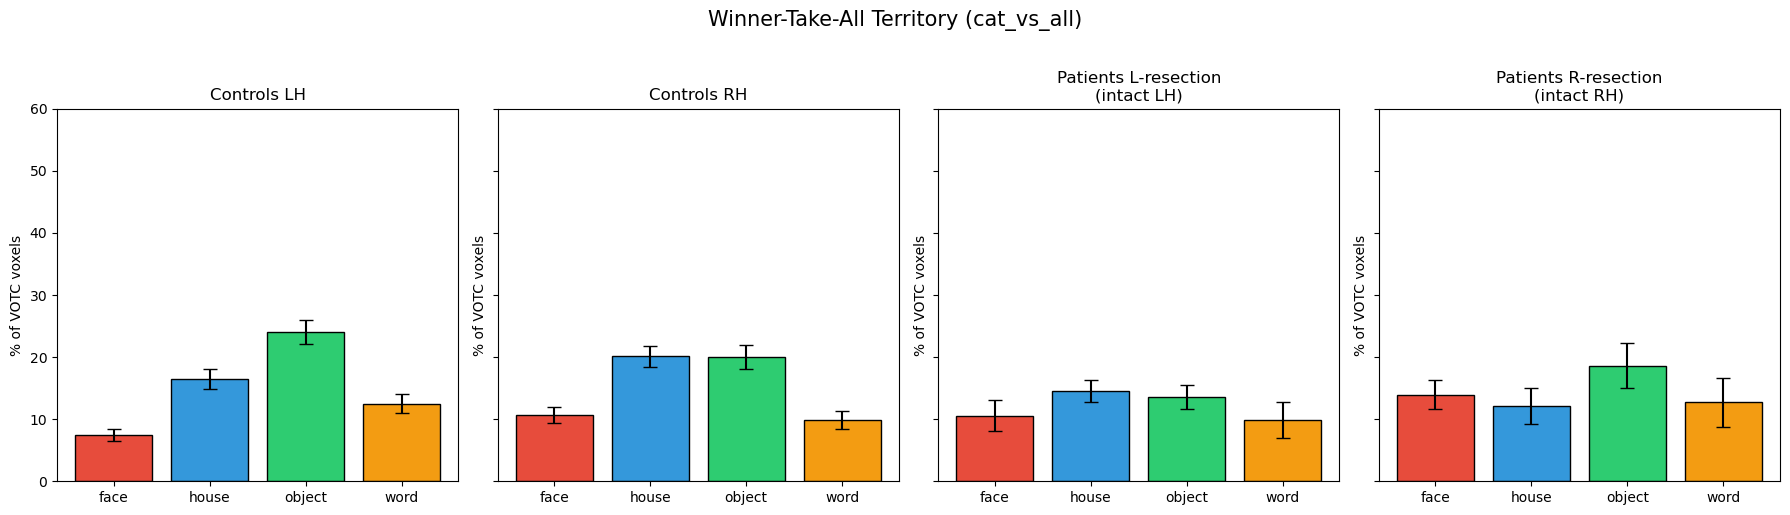

In [5]:
# ── Bar chart: Average territory per category ─────────────────────────────────

panels = [
    ('Controls LH', 'control', 'l', None),
    ('Controls RH', 'control', 'r', None),
    ('Patients L-resection\n(intact LH)', 'OTC', 'l', 'right'),
    ('Patients R-resection\n(intact RH)', 'OTC', 'r', 'left'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for ax, (title, group, hemi, surg) in zip(axes, panels):
    pct_rows = []
    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group or h != hemi:
            continue
        if surg is not None and res.get('surgery_side', 'na') != surg:
            continue
        pct_rows.append(res['pcts'])

    if not pct_rows:
        ax.set_title(f"{title}\n(no data)")
        continue

    df = pd.DataFrame(pct_rows)
    means = df[CATEGORIES].mean()
    sems = df[CATEGORIES].sem()

    ax.bar(CATEGORIES, means, yerr=sems, capsize=5,
           color=[CAT_COLORS[c] for c in CATEGORIES], edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('% of VOTC voxels')
    ax.set_ylim(0, 60)

plt.suptitle(f'Winner-Take-All Territory ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'wta_territory_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Longitudinal Transition Matrices

In [6]:
# ── Compute transitions for longitudinal subjects ────────────────────────────

transition_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']

    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue

        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue

        winners_t1, margin_t1, _ = compute_wta(betas_t1, threshold)
        winners_t2, margin_t2, _ = compute_wta(betas_t2, threshold)

        trans, trans_pct, retention = compute_transition_matrix(winners_t1, winners_t2)

        transition_results[(sid, h)] = {
            'trans_counts': trans, 'trans_pct': trans_pct, 'retention': retention,
            'winners_t1': winners_t1, 'winners_t2': winners_t2,
            'margin_t1': margin_t1, 'margin_t2': margin_t2,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            't1_ses': t1_ses, 't2_ses': t2_ses, 'info': info,
        }

print(f"Computed transitions for {len(transition_results)} subject-hemisphere entries")

Computed transitions for 27 subject-hemisphere entries


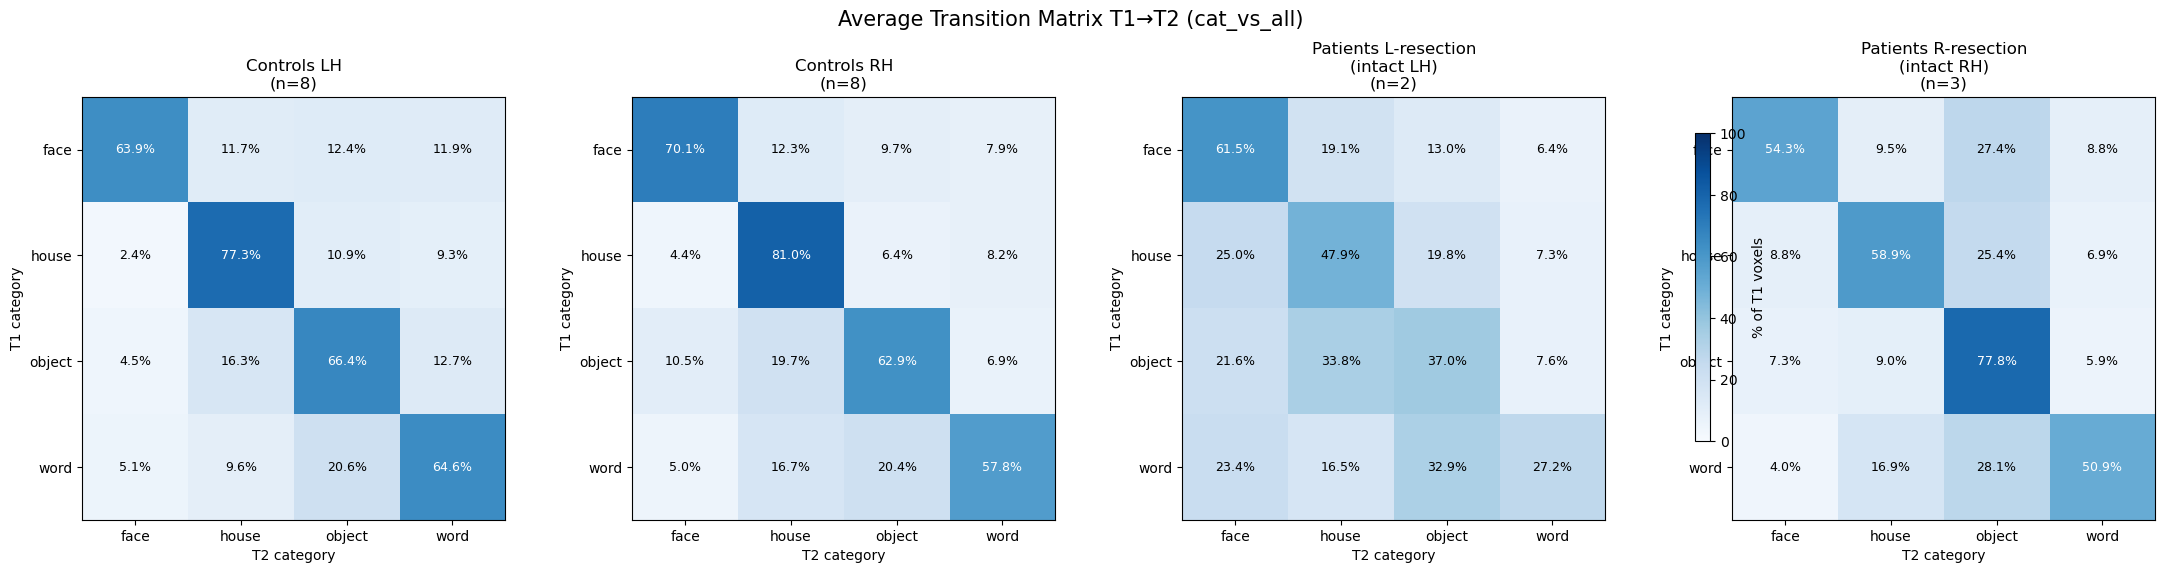

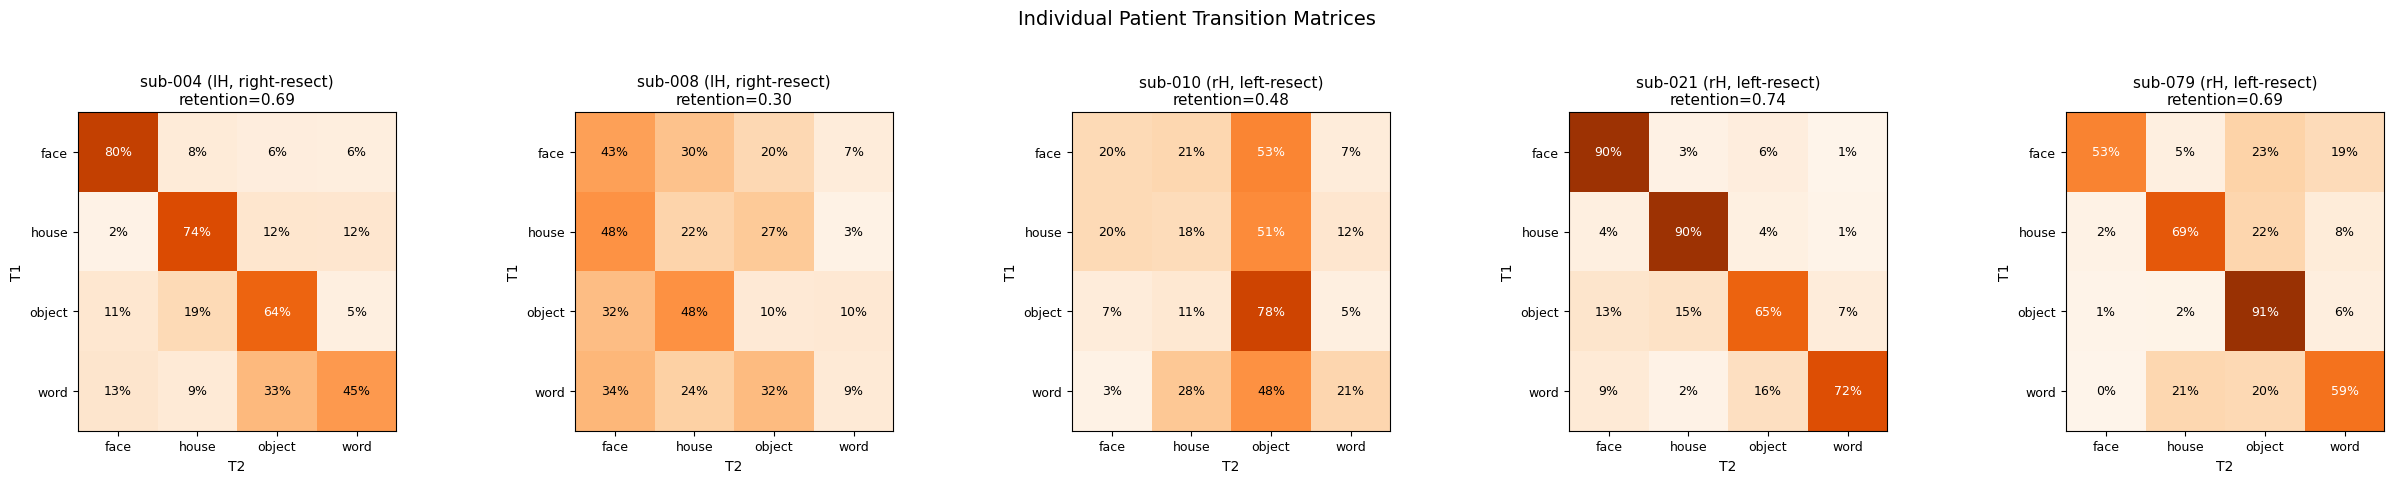

In [7]:
# ── Average transition heatmaps + individual patient matrices ─────────────────

def avg_transition_matrix(results, group, hemi=None, surgery_side=None):
    matrices, sids = [], []
    for (sid, h), res in results.items():
        if res['group'] != group:
            continue
        if hemi is not None and h != hemi:
            continue
        if surgery_side is not None and res.get('surgery_side', 'na') != surgery_side:
            continue
        matrices.append(res['trans_pct'])
        sids.append(sid)
    if not matrices:
        return None, []
    return np.mean(matrices, axis=0), sids


# Group average heatmaps
panels = [
    ('Controls LH', 'control', 'l', None),
    ('Controls RH', 'control', 'r', None),
    ('Patients L-resection\n(intact LH)', 'OTC', 'l', 'right'),
    ('Patients R-resection\n(intact RH)', 'OTC', 'r', 'left'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (title, group, hemi, surg) in zip(axes, panels):
    avg_mat, sids = avg_transition_matrix(transition_results, group, hemi, surg)
    if avg_mat is None:
        ax.set_title(f"{title}\n(no data)")
        ax.axis('off')
        continue

    im = ax.imshow(avg_mat, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CATEGORIES, fontsize=10)
    ax.set_yticklabels(CATEGORIES, fontsize=10)
    ax.set_xlabel('T2 category'); ax.set_ylabel('T1 category')
    ax.set_title(f'{title}\n(n={len(sids)})', fontsize=12)

    for i in range(4):
        for j in range(4):
            color = 'white' if avg_mat[i, j] > 50 else 'black'
            ax.text(j, i, f'{avg_mat[i, j]:.1f}%', ha='center', va='center',
                    fontsize=9, color=color)

plt.colorbar(im, ax=axes, shrink=0.8, label='% of T1 voxels')
plt.suptitle(f'Average Transition Matrix T1→T2 ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'transition_matrix_split_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()

# Individual patient heatmaps
patient_trans = {k: v for k, v in transition_results.items() if v['group'] == 'OTC'}

if patient_trans:
    n_patients = len(patient_trans)
    fig, axes = plt.subplots(1, n_patients, figsize=(5 * n_patients, 4.5))
    if n_patients == 1:
        axes = [axes]

    for ax, ((sid, h), res) in zip(axes, patient_trans.items()):
        im = ax.imshow(res['trans_pct'], cmap='Oranges', vmin=0, vmax=100)
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(CATEGORIES, fontsize=9)
        ax.set_yticklabels(CATEGORIES, fontsize=9)
        ax.set_xlabel('T2'); ax.set_ylabel('T1')
        surgery = res.get('surgery_side', '?')
        ax.set_title(f'{sid} ({h}H, {surgery}-resect)\n'
                     f'retention={res["retention"]:.2f}', fontsize=11)

        for i in range(4):
            for j in range(4):
                color = 'white' if res['trans_pct'][i, j] > 50 else 'black'
                ax.text(j, i, f'{res["trans_pct"][i, j]:.0f}%',
                        ha='center', va='center', fontsize=9, color=color)

    plt.suptitle('Individual Patient Transition Matrices', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(processed_dir, 'group_results',
                f'patient_transitions_{ALLEGIANCE_COPE_SET}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

## 3. Voxel Profile Stability

In [8]:
# ── Compute profile stability for longitudinal subjects ──────────────────────

stability_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']

    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue

        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue

        cos_sims, mean_cos, median_cos = compute_profile_stability(betas_t1, betas_t2)

        stability_results[(sid, h)] = {
            'cos_sims': cos_sims, 'mean_cos': mean_cos, 'median_cos': median_cos,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'), 'info': info,
        }

print(f"Computed profile stability for {len(stability_results)} entries")

# Summary table
stab_rows = []
for (sid, h), res in stability_results.items():
    stab_rows.append({
        'sub': sid, 'hemi': h, 'group': res['group'],
        'surgery_side': res.get('surgery_side', 'na'),
        'mean_cos_sim': res['mean_cos'], 'median_cos_sim': res['median_cos'],
    })

stab_df = pd.DataFrame(stab_rows)
print("\n=== PROFILE STABILITY (cosine similarity T1 vs T2) ===\n")
print(stab_df.groupby(['group', 'surgery_side'])[['mean_cos_sim', 'median_cos_sim']].describe().round(3))

Computed profile stability for 27 entries

=== PROFILE STABILITY (cosine similarity T1 vs T2) ===

                     mean_cos_sim                                            \
                            count   mean    std    min    25%    50%    75%   
group   surgery_side                                                          
OTC     left                  3.0  0.339  0.232  0.074  0.258  0.441  0.472   
        right                 2.0  0.212  0.095  0.144  0.178  0.212  0.245   
control na                   16.0  0.464  0.107  0.266  0.404  0.467  0.548   
nonOTC  left                  4.0  0.492  0.082  0.384  0.467  0.500  0.525   
        right                 2.0  0.545  0.066  0.498  0.522  0.545  0.568   

                            median_cos_sim                                     \
                        max          count   mean    std    min    25%    50%   
group   surgery_side                                                            
OTC     left          0.5

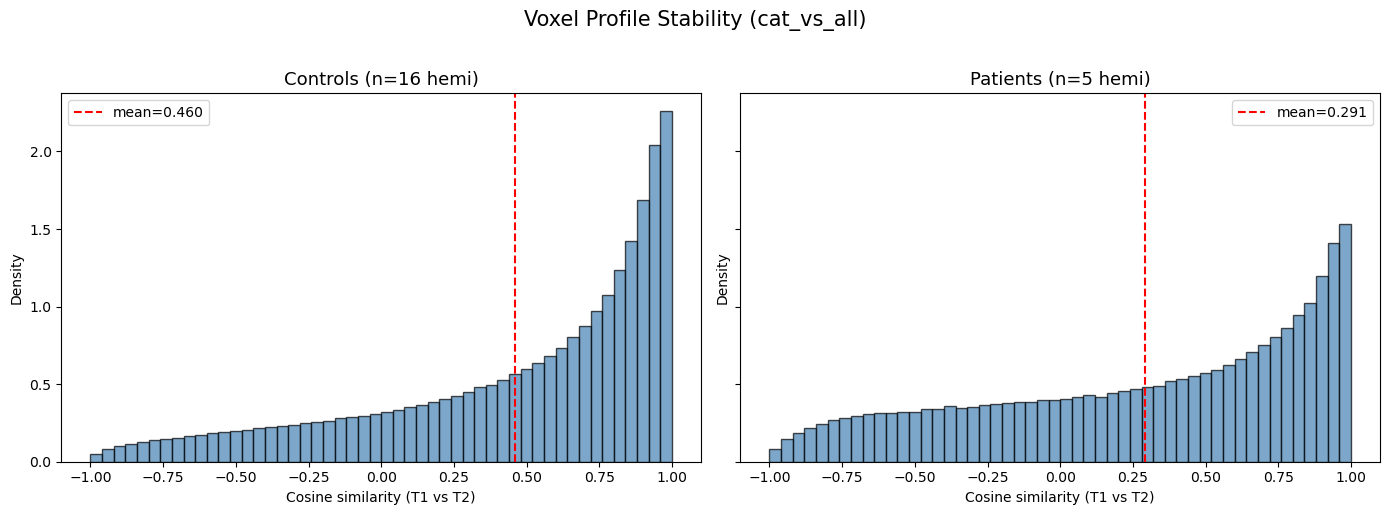

In [9]:
# ── Histogram of cosine similarities ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (title, group) in zip(axes, [('Controls', 'control'), ('Patients', 'OTC')]):
    all_cos = []
    for (sid, h), res in stability_results.items():
        if res['group'] != group:
            continue
        all_cos.append(res['cos_sims'])

    if not all_cos:
        ax.set_title(f"{title} (no data)")
        continue

    pooled = np.concatenate(all_cos)
    pooled = pooled[np.isfinite(pooled)]

    ax.hist(pooled, bins=50, range=(-1, 1), density=True, alpha=0.7,
            color='steelblue', edgecolor='black')
    ax.axvline(np.mean(pooled), color='red', linestyle='--', label=f'mean={np.mean(pooled):.3f}')
    ax.set_xlabel('Cosine similarity (T1 vs T2)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title} (n={len(all_cos)} hemi)', fontsize=13)
    ax.legend()

plt.suptitle(f'Voxel Profile Stability ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'profile_stability_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()

PROFILE STABILITY: THRESHOLDED (z > 1.96)
Only voxels selective for at least one category at T1

       Sub  Hemi    Group   N sel  % sel Thresh cos   Orig cos
   sub-004     l      OTC   33309  32.1%      0.578      0.279
   sub-007     l   nonOTC   52808  43.1%      0.571      0.384
   sub-007     r   nonOTC   59920  49.6%      0.730      0.583
   sub-008     l      OTC   38861  48.8%      0.177      0.144
   sub-010     r      OTC   41899  36.3%      0.155      0.074
   sub-018     l  control   54058  58.8%      0.619      0.453
   sub-018     r  control   56171  61.8%      0.603      0.481
   sub-021     r      OTC   38151  47.8%      0.710      0.502
   sub-022     l  control   64050  62.1%      0.509      0.395
   sub-022     r  control   54613  53.8%      0.486      0.355
   sub-025     l  control   75017  65.5%      0.612      0.440
   sub-025     r  control   72769  64.3%      0.649      0.511
   sub-045     l   nonOTC   61288  67.2%      0.676      0.495
   sub-045     r   no

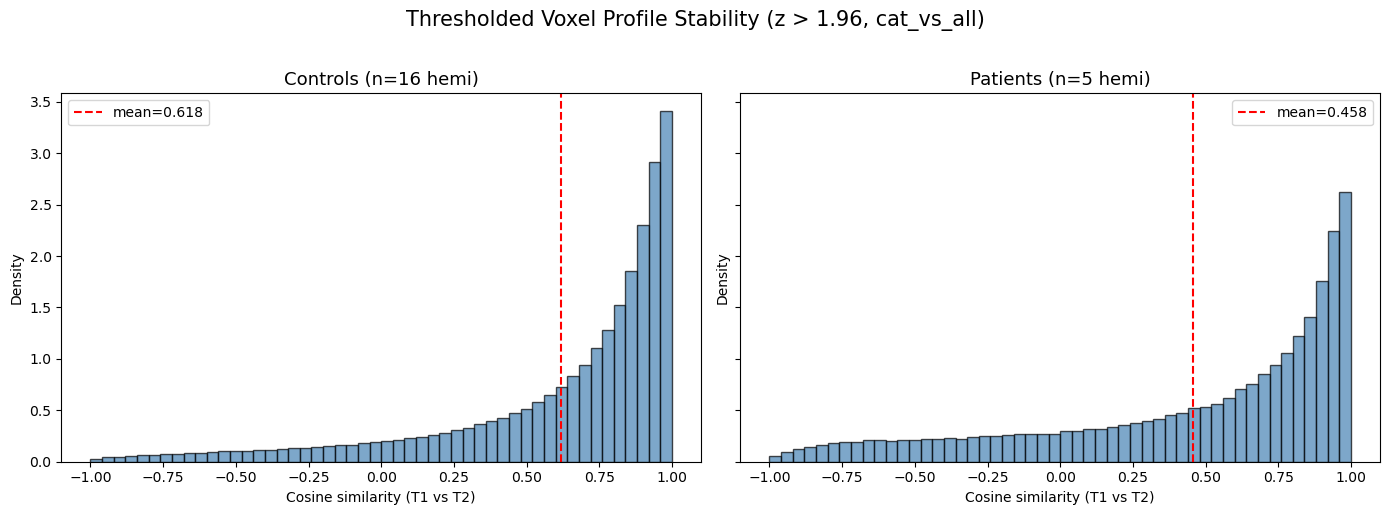


CRAWFORD'S t: Thresholded cosine (z > 1.96)

  sub-004 (LH, right-resection) — ANATOMICAL (vs Ctrl LH):
     overall: pt=0.578, ctrl=0.623, t=-0.37, p=0.7205
        face: pt=0.602, ctrl=0.504, t=+0.44, p=0.6755
       house: pt=0.521, ctrl=0.632, t=-0.67, p=0.5231
      object: pt=0.629, ctrl=0.687, t=-0.58, p=0.5815
        word: pt=0.513, ctrl=0.609, t=-0.63, p=0.5507
  sub-004 (LH, right-resection) — FUNCTIONAL:
        face: pt=0.602, ctrl_RH=0.592, t=+0.06, p=0.9556
       house: pt=0.521, ctrl_both=0.641, t=-0.71, p=0.4874
      object: pt=0.629, ctrl_both=0.680, t=-0.60, p=0.5556
        word: pt=0.513, ctrl_LH=0.609, t=-0.63, p=0.5507

  sub-008 (LH, right-resection) — ANATOMICAL (vs Ctrl LH):
     overall: pt=0.177, ctrl=0.623, t=-3.71, p=0.0076 *
        face: pt=0.194, ctrl=0.504, t=-1.37, p=0.2125
       house: pt=0.194, ctrl=0.632, t=-2.66, p=0.0323 *
      object: pt=0.123, ctrl=0.687, t=-5.64, p=0.0008 *
        word: pt=0.138, ctrl=0.609, t=-3.09, p=0.0176 *
  sub-008

In [19]:
# ── Thresholded Profile Stability ────────────────────────────────────────────
# Only voxels selective for at least one category at T1 (z > 1.96)
# Removes noise floor from non-selective voxels

STABILITY_THRESHOLD = 1.96

thresh_stability = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue

        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue

        mat_t1 = np.column_stack([betas_t1[cat] for cat in CATEGORIES])
        mat_t2 = np.column_stack([betas_t2[cat] for cat in CATEGORIES])

        # Only voxels where at least one category passes threshold at T1
        max_t1 = np.max(mat_t1, axis=1)
        selective = max_t1 > STABILITY_THRESHOLD
        n_selective = int(selective.sum())
        n_total = len(max_t1)

        if n_selective == 0:
            continue

        # Cosine similarity on selective voxels only
        m1, m2 = mat_t1[selective], mat_t2[selective]
        dot = np.sum(m1 * m2, axis=1)
        n1, n2 = np.linalg.norm(m1, axis=1), np.linalg.norm(m2, axis=1)
        denom = n1 * n2
        valid = denom > 0
        cos_sims = np.full(n_selective, np.nan)
        cos_sims[valid] = dot[valid] / denom[valid]

        # Per-category cosine (using T1 WTA on selective voxels)
        winners_t1, _, _ = compute_wta(betas_t1, STABILITY_THRESHOLD)
        cat_cos = {}
        for i, cat in enumerate(CATEGORIES):
            combined = (winners_t1 == i) & selective
            if combined.sum() > 10:
                mc1 = mat_t1[combined]
                mc2 = mat_t2[combined]
                d = np.sum(mc1 * mc2, axis=1)
                nn1, nn2 = np.linalg.norm(mc1, axis=1), np.linalg.norm(mc2, axis=1)
                dd = nn1 * nn2
                vv = dd > 0
                cs = np.full(combined.sum(), np.nan)
                cs[vv] = d[vv] / dd[vv]
                cat_cos[cat] = np.nanmean(cs)
            else:
                cat_cos[cat] = np.nan

        group = info['patient_status']
        surgery = info.get('surgery_side', 'na')

        thresh_stability[(sid, h)] = {
            'cos_sims': cos_sims, 'mean_cos': np.nanmean(cos_sims),
            'median_cos': np.nanmedian(cos_sims), 'cat_cos': cat_cos,
            'n_selective': n_selective, 'n_total': n_total,
            'pct_selective': n_selective / n_total * 100,
            'group': group, 'surgery_side': surgery, 'hemi': h,
        }

# ── Print: thresholded vs unthresholded ──────────────────────────────────────

print("=" * 70)
print(f"PROFILE STABILITY: THRESHOLDED (z > {STABILITY_THRESHOLD})")
print("Only voxels selective for at least one category at T1")
print("=" * 70)

print(f"\n{'Sub':>10} {'Hemi':>5} {'Group':>8} {'N sel':>7} {'% sel':>6} "
      f"{'Thresh cos':>10} {'Orig cos':>10}")
for (sid, h), res in sorted(thresh_stability.items()):
    orig = stability_results.get((sid, h), {}).get('mean_cos', np.nan)
    print(f"{sid:>10} {h:>5} {res['group']:>8} {res['n_selective']:>7} "
          f"{res['pct_selective']:>5.1f}% {res['mean_cos']:>10.3f} {orig:>10.3f}")

# ── Histogram: thresholded ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (title, group) in zip(axes, [('Controls', 'control'), ('Patients', 'OTC')]):
    all_cos = []
    for (sid, h), res in thresh_stability.items():
        if res['group'] != group:
            continue
        all_cos.append(res['cos_sims'])

    if not all_cos:
        ax.set_title(f"{title} (no data)")
        continue

    pooled = np.concatenate(all_cos)
    pooled = pooled[np.isfinite(pooled)]

    ax.hist(pooled, bins=50, range=(-1, 1), density=True, alpha=0.7,
            color='steelblue', edgecolor='black')
    ax.axvline(np.mean(pooled), color='red', linestyle='--',
               label=f'mean={np.mean(pooled):.3f}')
    ax.set_xlabel('Cosine similarity (T1 vs T2)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title} (n={len(all_cos)} hemi)', fontsize=13)
    ax.legend()

plt.suptitle(f'Thresholded Voxel Profile Stability (z > {STABILITY_THRESHOLD}, {ALLEGIANCE_COPE_SET})',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'profile_stability_thresh_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Crawford's t: anatomical + functional ────────────────────────────────────

ctrl_cos_thresh = {'l': {cat: [] for cat in CATEGORIES},
                   'r': {cat: [] for cat in CATEGORIES}}
ctrl_overall_thresh = {'l': [], 'r': []}

for (sid, h), res in thresh_stability.items():
    if res['group'] != 'control':
        continue
    ctrl_overall_thresh[h].append(res['mean_cos'])
    for cat in CATEGORIES:
        val = res['cat_cos'].get(cat, np.nan)
        if np.isfinite(val):
            ctrl_cos_thresh[h][cat].append(val)

print("\n" + "=" * 70)
print(f"CRAWFORD'S t: Thresholded cosine (z > {STABILITY_THRESHOLD})")
print("=" * 70)

for (sid, h), res in sorted(thresh_stability.items()):
    if res['group'] != 'OTC':
        continue

    surgery = res['surgery_side']
    label = 'LH' if h == 'l' else 'RH'

    # --- Anatomical ---
    print(f"\n  {sid} ({label}, {surgery}-resection) — ANATOMICAL (vs Ctrl {label}):")
    pt_val = res['mean_cos']
    ctrl_vals = np.array(ctrl_overall_thresh[h])
    if len(ctrl_vals) >= 2:
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        print(f"    {'overall':>8}: pt={pt_val:.3f}, ctrl={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")
    for cat in CATEGORIES:
        pt_val = res['cat_cos'].get(cat, np.nan)
        ctrl_vals = np.array(ctrl_cos_thresh[h][cat])
        if not np.isfinite(pt_val) or len(ctrl_vals) < 2:
            continue
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        print(f"    {cat:>8}: pt={pt_val:.3f}, ctrl={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")

    # --- Functional ---
    print(f"  {sid} ({label}, {surgery}-resection) — FUNCTIONAL:")
    for cat in CATEGORIES:
        pt_val = res['cat_cos'].get(cat, np.nan)
        ctrl_vals = np.array(get_functional_ctrl_vals(ctrl_cos_thresh, cat))
        if not np.isfinite(pt_val) or len(ctrl_vals) < 2:
            continue
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        func_h = FUNCTIONAL_HEMI[cat]
        func_label = f"{'both' if func_h is None else ('LH' if func_h == 'l' else 'RH')}"
        print(f"    {cat:>8}: pt={pt_val:.3f}, ctrl_{func_label}={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")

## 4. Blauch-Style Summed Selectivity

In [10]:
# ── Compute summed selectivity: longitudinal subjects, all sessions ──────────
# Always uses cat_vs_all copes (6-9) regardless of ALLEGIANCE_COPE_SET

sumsel_cope_map = CAT_VS_ALL_COPES
sumsel_rows = []

for sid, info in long_subs.items():
    sessions = info['sessions']
    actual_first = info['actual_first_ses']
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue
        mask_size = int(mask.sum())

        for ses in sessions:
            betas = load_category_betas(sid, ses, actual_first, mask, sumsel_cope_map)
            if betas is None:
                continue

            ss = compute_summed_selectivity(betas, mask_size)

            for cat, vals in ss.items():
                sumsel_rows.append({
                    'sub': sid, 'ses': ses, 'hemi': h,
                    'group': info['patient_status'],
                    'surgery_side': info.get('surgery_side', 'na'),
                    'category': cat, **vals,
                })

sumsel_df = pd.DataFrame(sumsel_rows)
if not sumsel_df.empty:
    print("=== SUMMED SELECTIVITY (cat_vs_all copes) ===\n")
    for sid in sorted(long_subs.keys()):
        sub_df = sumsel_df[sumsel_df['sub'] == sid]
        if sub_df.empty:
            continue
        sessions = sorted(sub_df['ses'].unique())
        if len(sessions) < 2:
            continue

        group = long_subs[sid]['patient_status']
        surgery = long_subs[sid].get('surgery_side', 'na')
        print(f"\n{sid} ({group}, {surgery}-resection):")
        for cat in CATEGORIES:
            t1_vals = sub_df[(sub_df['ses'] == sessions[0]) & (sub_df['category'] == cat)]['summed_sel']
            t2_vals = sub_df[(sub_df['ses'] == sessions[-1]) & (sub_df['category'] == cat)]['summed_sel']
            if t1_vals.empty or t2_vals.empty:
                continue
            t1_val, t2_val = t1_vals.iloc[0], t2_vals.iloc[0]
            print(f"  {cat:8s}: T1={t1_val:10.1f}  T2={t2_val:10.1f}  Δ={t2_val - t1_val:+10.1f}")

=== SUMMED SELECTIVITY (cat_vs_all copes) ===


sub-004 (OTC, right-resection):
  face    : T1=   17878.8  T2=   55337.5  Δ=  +37458.8
  house   : T1=   97268.6  T2=  141323.5  Δ=  +44054.9
  object  : T1=   88763.3  T2=  135035.3  Δ=  +46272.0
  word    : T1=    9884.6  T2=   68831.2  Δ=  +58946.6

sub-007 (nonOTC, left-resection):
  face    : T1=   83756.2  T2=   79592.1  Δ=   -4164.1
  house   : T1=  150406.3  T2=   88697.7  Δ=  -61708.6
  object  : T1=  120616.3  T2=  109086.0  Δ=  -11530.3
  word    : T1=   46920.7  T2=   48914.5  Δ=   +1993.8

sub-008 (OTC, right-resection):
  face    : T1=  115467.2  T2=   63324.0  Δ=  -52143.2
  house   : T1=   89738.4  T2=   46493.6  Δ=  -43244.8
  object  : T1=   78081.3  T2=   32431.0  Δ=  -45650.3
  word    : T1=   21709.6  T2=   24119.9  Δ=   +2410.3

sub-010 (OTC, left-resection):
  face    : T1=   88875.1  T2=   46430.1  Δ=  -42445.0
  house   : T1=   69074.9  T2=   48417.5  Δ=  -20657.4
  object  : T1=  121262.3  T2=  104768.0  Δ=  -164

## 5. Margin Analysis

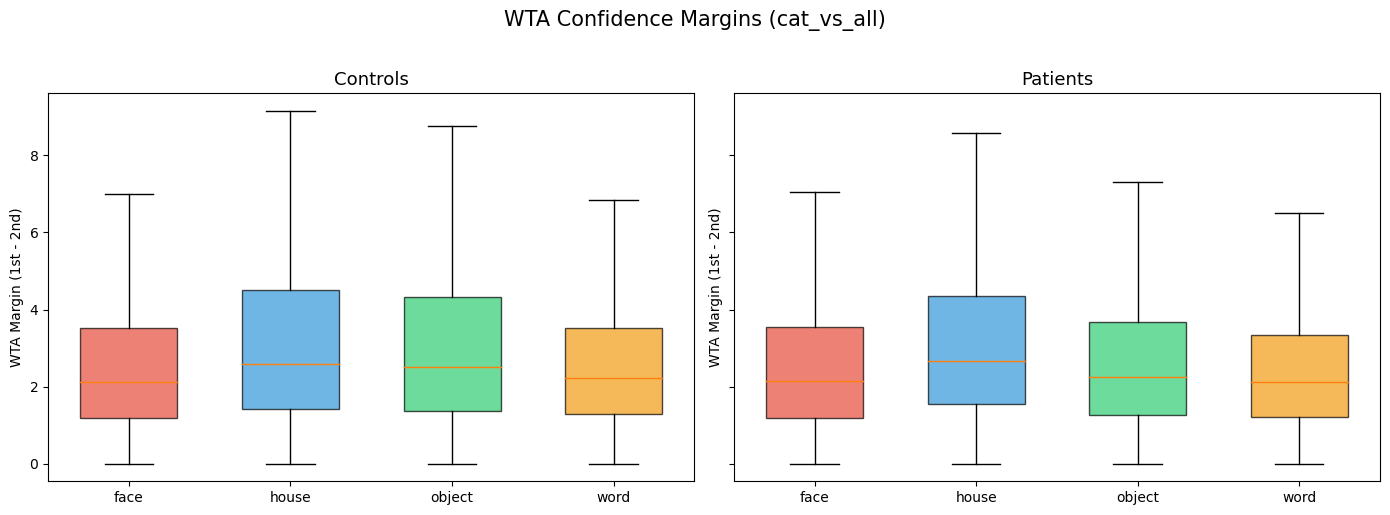


=== MARGIN CHANGE T1→T2 ===
Positive = more committed, Negative = less committed

category               face  house  object   word
group   surgery_side                             
OTC     left         -0.260 -0.687  -0.226  0.019
        right        -0.276 -0.443   0.170 -0.437
control na            0.264  0.516  -0.414  0.059
nonOTC  left         -1.092 -2.193  -0.301 -0.897
        right         2.012  1.040   0.074  0.413


In [11]:
# ── Cross-sectional: WTA margin distributions ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (title, group) in zip(axes, [('Controls', 'control'), ('Patients', 'OTC')]):
    all_margins = {cat: [] for cat in CATEGORIES}

    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group:
            continue
        for i, cat in enumerate(CATEGORIES):
            cat_mask = res['winners'] == i
            if cat_mask.sum() > 0:
                all_margins[cat].append(res['margin'][cat_mask])

    positions, data, colors = [], [], []
    for i, cat in enumerate(CATEGORIES):
        if all_margins[cat]:
            data.append(np.concatenate(all_margins[cat]))
            positions.append(i)
            colors.append(CAT_COLORS[cat])

    if data:
        bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                        showfliers=False)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_xticks(range(4))
        ax.set_xticklabels(CATEGORIES)

    ax.set_ylabel('WTA Margin (1st - 2nd)')
    ax.set_title(f'{title}', fontsize=13)

plt.suptitle(f'WTA Confidence Margins ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'wta_margins_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Longitudinal: margin change T1→T2 ────────────────────────────────────────

margin_change_rows = []

for (sid, h), res in transition_results.items():
    for i, cat in enumerate(CATEGORIES):
        cat_at_t1 = res['winners_t1'] == i
        if cat_at_t1.sum() == 0:
            continue
        mean_margin_t1 = np.mean(res['margin_t1'][cat_at_t1])
        mean_margin_t2 = np.mean(res['margin_t2'][cat_at_t1])
        margin_change_rows.append({
            'sub': sid, 'hemi': h,
            'group': res['group'],
            'surgery_side': res.get('surgery_side', 'na'),
            'category': cat,
            'mean_margin_t1': mean_margin_t1,
            'mean_margin_t2': mean_margin_t2,
            'margin_change': mean_margin_t2 - mean_margin_t1,
            'n_voxels': int(cat_at_t1.sum()),
        })

margin_df = pd.DataFrame(margin_change_rows)
if not margin_df.empty:
    print("\n=== MARGIN CHANGE T1→T2 ===")
    print("Positive = more committed, Negative = less committed\n")
    pivot = margin_df.pivot_table(values='margin_change',
                                   index=['group', 'surgery_side'],
                                   columns='category', aggfunc='mean').round(3)
    print(pivot)

## 6. Relocating vs. Resident Stability

In [12]:
# ── Build per-subject, per-category cosine values ─────────────────────────────

all_cat_cos = {}

for (sid, h), res in stability_results.items():
    if (sid, h) not in transition_results:
        continue

    group = res['group']
    surgery = res.get('surgery_side', res.get('info', {}).get('surgery_side', 'na'))
    winners_t1 = transition_results[(sid, h)]['winners_t1']
    cos_sims = res['cos_sims']

    cat_cos = {}
    for i, cat in enumerate(CATEGORIES):
        cat_mask = winners_t1 == i
        if cat_mask.sum() > 10:
            cat_cos[cat] = np.nanmean(cos_sims[cat_mask])
        else:
            cat_cos[cat] = np.nan

    all_cat_cos[(sid, h)] = {
        'cat_cos': cat_cos, 'group': group,
        'surgery_side': surgery, 'hemi': h,
    }

# ── Relocating - Resident difference ─────────────────────────────────────────
# Relocating = lateralized category displaced from preferred hemisphere
#   R-resection (intact LH): face is relocating (face prefers RH)
#   L-resection (intact RH): word is relocating (word prefers LH)

reloc_diff_rows = []

for (sid, h), info in all_cat_cos.items():
    cat_cos = info['cat_cos']

    if h == 'l':
        relocating = 'face'
    else:
        relocating = 'word'

    residents = [cat for cat in CATEGORIES if cat != relocating]
    reloc_val = cat_cos.get(relocating, np.nan)
    resident_mean = np.nanmean([cat_cos.get(cat, np.nan) for cat in residents])
    diff = reloc_val - resident_mean if np.isfinite(reloc_val) and np.isfinite(resident_mean) else np.nan

    reloc_diff_rows.append({
        'sub': sid, 'hemi': h, 'group': info['group'],
        'surgery_side': info['surgery_side'],
        'relocating': relocating,
        'reloc_cosine': reloc_val, 'resident_mean_cosine': resident_mean,
        'reloc_minus_resident': diff,
    })

reloc_df = pd.DataFrame(reloc_diff_rows)

print("=" * 70)
print("RELOCATING vs RESIDENT PROFILE STABILITY")
print("  LH: face (prefers RH) | RH: word (prefers LH)")
print("=" * 70)

print(f"\n{'Sub':>10} {'Hemi':>5} {'Group':>8} {'Reloc':>6} {'Reloc cos':>10} {'Resid cos':>10} {'Diff':>8}")
for _, row in reloc_df.sort_values(['group', 'sub', 'hemi']).iterrows():
    print(f"{row['sub']:>10} {row['hemi']:>5} {row['group']:>8} {row['relocating']:>6} "
          f"{row['reloc_cosine']:>10.3f} {row['resident_mean_cosine']:>10.3f} "
          f"{row['reloc_minus_resident']:>+8.3f}")

# Crawford's t
print("\n" + "=" * 70)
print("CRAWFORD'S t: Relocating-Resident difference vs Controls")
print("=" * 70)

ctrl_diffs = {'l': [], 'r': []}
for _, row in reloc_df.iterrows():
    if row['group'] == 'control' and np.isfinite(row['reloc_minus_resident']):
        ctrl_diffs[row['hemi']].append(row['reloc_minus_resident'])

for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    vals = ctrl_diffs[h]
    print(f"\nControl {label} (n={len(vals)}): M={np.mean(vals):+.3f} SD={np.std(vals, ddof=1):.3f}")

for _, row in reloc_df.sort_values('sub').iterrows():
    if row['group'] != 'OTC' or not np.isfinite(row['reloc_minus_resident']):
        continue
    h = row['hemi']
    ctrl_vals = np.array(ctrl_diffs[h])
    pt_val = row['reloc_minus_resident']
    t_val, p_val = crawford_t(pt_val, ctrl_vals)
    sig = ' *' if p_val < .05 else ''
    label = 'LH' if h == 'l' else 'RH'
    print(f"  {row['sub']} ({label}, reloc={row['relocating']}): "
          f"diff={pt_val:+.3f}, t={t_val:+.2f}, p={p_val:.4f}{sig}")

RELOCATING vs RESIDENT PROFILE STABILITY
  LH: face (prefers RH) | RH: word (prefers LH)

       Sub  Hemi    Group  Reloc  Reloc cos  Resid cos     Diff
   sub-004     l      OTC   face      0.602      0.555   +0.048
   sub-008     l      OTC   face      0.194      0.152   +0.042
   sub-010     r      OTC   word     -0.015      0.141   -0.156
   sub-021     r      OTC   word      0.800      0.789   +0.011
   sub-079     r      OTC   word      0.347      0.625   -0.278
   sub-018     l  control   face      0.376      0.658   -0.282
   sub-018     r  control   word      0.200      0.595   -0.395
   sub-022     l  control   face      0.346      0.524   -0.178
   sub-022     r  control   word      0.182      0.612   -0.430
   sub-025     l  control   face      0.310      0.670   -0.360
   sub-025     r  control   word      0.445      0.634   -0.188
   sub-052     l  control   face      0.661      0.611   +0.050
   sub-052     r  control   word      0.417      0.653   -0.236
   sub-058    

## 7. Statistics: Anatomical vs. Functional Homolog Comparisons

Two comparison frameworks:
1. **Anatomical homolog**: patient intact LH → control LH; patient intact RH → control RH
2. **Functional homolog**: for each category, compare patient to the hemisphere where that category typically lives in controls (face→RH, word→LH, object/house→both)

In [13]:
# ── Build per-subject retention + cosine table ────────────────────────────────

ret_rows = []

for sid, info in long_subs.items():
    group = info['patient_status']
    surgery = info.get('surgery_side', 'na')
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        if (sid, h) not in transition_results:
            continue

        res = transition_results[(sid, h)]
        tc = res['trans_counts']

        row = {
            'sub': sid, 'hemi': h, 'group': group,
            'surgery_side': surgery,
            'overall_retention': res['retention'],
        }

        for i, cat in enumerate(CATEGORIES):
            row_total = tc[i, :].sum()
            row[f'{cat}_retention'] = tc[i, i] / row_total if row_total > 0 else np.nan

        if (sid, h) in all_cat_cos:
            for cat in CATEGORIES:
                row[f'{cat}_cosine'] = all_cat_cos[(sid, h)]['cat_cos'].get(cat, np.nan)

        if (sid, h) in stability_results:
            row['mean_cos_sim'] = stability_results[(sid, h)]['mean_cos']

        ret_rows.append(row)

ret_subject = pd.DataFrame(ret_rows)
ctrl_ret = ret_subject[ret_subject['group'] == 'control']
otc_ret = ret_subject[ret_subject['group'] == 'OTC']

# Build control distributions by hemisphere (used by both frameworks)
ctrl_ret_by_hemi = {'l': {cat: [] for cat in CATEGORIES + ['overall']},
                    'r': {cat: [] for cat in CATEGORIES + ['overall']}}

for _, row in ctrl_ret.iterrows():
    h = row['hemi']
    ctrl_ret_by_hemi[h]['overall'].append(row['overall_retention'])
    for cat in CATEGORIES:
        val = row[f'{cat}_retention']
        if np.isfinite(val):
            ctrl_ret_by_hemi[h][cat].append(val)

ctrl_cos_by_hemi = {'l': {cat: [] for cat in CATEGORIES},
                    'r': {cat: [] for cat in CATEGORIES}}
for (sid, h), info in all_cat_cos.items():
    if info['group'] != 'control':
        continue
    for cat in CATEGORIES:
        val = info['cat_cos'].get(cat, np.nan)
        if np.isfinite(val):
            ctrl_cos_by_hemi[h][cat].append(val)

# Pre-compute functional homolog control distributions
ctrl_ret_functional = {cat: get_functional_ctrl_vals(ctrl_ret_by_hemi, cat) for cat in CATEGORIES}

print(f"Retention table: {len(ret_subject)} entries "
      f"({len(ctrl_ret)} control, {len(otc_ret)} OTC)")

Retention table: 27 entries (16 control, 5 OTC)


### 7a. Anatomical Homolog: Retention

In [14]:
# ── Anatomical homolog: hemisphere-matched per-category retention ─────────────

print("=" * 70)
print("ANATOMICAL HOMOLOG: Per-category retention")
print("Patient intact LH → Control LH | Patient intact RH → Control RH")
print("=" * 70)

print("\n--- Group means [95% CI], by hemisphere ---")
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    print(f"\n  {label}:")
    for cat in CATEGORIES + ['overall']:
        col = f'{cat}_retention' if cat != 'overall' else 'overall_retention'
        ctrl_vals = ctrl_ret_by_hemi[h][cat]
        otc_h = otc_ret[otc_ret['hemi'] == h]
        otc_vals = otc_h[col].dropna().values
        if len(ctrl_vals) >= 2:
            m, lo, hi = bootstrap_ci(ctrl_vals)
            print(f"    Ctrl {cat:>8} (n={len(ctrl_vals)}): {m:.3f} [{lo:.3f}, {hi:.3f}]")
        if len(otc_vals) >= 1:
            print(f"    OTC  {cat:>8} (n={len(otc_vals)}): {np.nanmean(otc_vals):.3f}")

print("\n" + "=" * 70)
print("CRAWFORD'S t: each OTC patient vs hemisphere-matched controls (ANATOMICAL)")
print("=" * 70)

for _, row in otc_ret.iterrows():
    sub, h, surgery = row['sub'], row['hemi'], row['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f"\n  {sub} ({label}, {surgery}-resection):")
    for cat in CATEGORIES + ['overall']:
        col = f'{cat}_retention' if cat != 'overall' else 'overall_retention'
        pt_val = row[col]
        ctrl_vals = np.array(ctrl_ret_by_hemi[h][cat])
        if not np.isfinite(pt_val) or len(ctrl_vals) < 2:
            continue
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        print(f"    {cat:>8}: val={pt_val:.3f}, ctrl={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")

ANATOMICAL HOMOLOG: Per-category retention
Patient intact LH → Control LH | Patient intact RH → Control RH

--- Group means [95% CI], by hemisphere ---

  LH:
    Ctrl     face (n=8): 0.639 [0.537, 0.738]
    OTC      face (n=2): 0.615
    Ctrl    house (n=8): 0.773 [0.690, 0.853]
    OTC     house (n=2): 0.479
    Ctrl   object (n=8): 0.664 [0.556, 0.766]
    OTC    object (n=2): 0.370
    Ctrl     word (n=8): 0.646 [0.485, 0.795]
    OTC      word (n=2): 0.272
    Ctrl  overall (n=8): 0.695 [0.647, 0.744]
    OTC   overall (n=2): 0.494

  RH:
    Ctrl     face (n=8): 0.701 [0.603, 0.793]
    OTC      face (n=3): 0.543
    Ctrl    house (n=8): 0.810 [0.722, 0.890]
    OTC     house (n=3): 0.589
    Ctrl   object (n=8): 0.629 [0.576, 0.683]
    OTC    object (n=3): 0.778
    Ctrl     word (n=8): 0.578 [0.354, 0.779]
    OTC      word (n=3): 0.509
    Ctrl  overall (n=8): 0.712 [0.654, 0.766]
    OTC   overall (n=3): 0.637

CRAWFORD'S t: each OTC patient vs hemisphere-matched controls (

### 7b. Functional Homolog: Retention
Face → Control RH | Word → Control LH | Object/House → Control both hemispheres

In [15]:
# ── Functional homolog: category-matched per-category retention ───────────────

print("=" * 70)
print("FUNCTIONAL HOMOLOG: Per-category retention")
print("=" * 70)

print("\n--- Functional homolog control distributions ---")
for cat in CATEGORIES:
    func_h = FUNCTIONAL_HEMI[cat]
    label = f"{'both' if func_h is None else ('LH' if func_h == 'l' else 'RH')}"
    vals = ctrl_ret_functional[cat]
    if vals:
        m, lo, hi = bootstrap_ci(vals)
        print(f"  {cat:>8} (Ctrl {label}, n={len(vals)}): {m:.3f} [{lo:.3f}, {hi:.3f}]")

print("\n" + "=" * 70)
print("CRAWFORD'S t: each OTC patient vs functional-homolog controls")
print("=" * 70)

for _, row in otc_ret.iterrows():
    sub, h, surgery = row['sub'], row['hemi'], row['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f"\n  {sub} (intact {label}, {surgery}-resection):")
    for cat in CATEGORIES:
        pt_val = row[f'{cat}_retention']
        ctrl_vals = np.array(ctrl_ret_functional[cat])
        if not np.isfinite(pt_val) or len(ctrl_vals) < 2:
            continue
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        func_h = FUNCTIONAL_HEMI[cat]
        func_label = f"{'both' if func_h is None else ('LH' if func_h == 'l' else 'RH')}"
        print(f"    {cat:>8}: val={pt_val:.3f}, ctrl_{func_label}={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")

FUNCTIONAL HOMOLOG: Per-category retention

--- Functional homolog control distributions ---
      face (Ctrl RH, n=8): 0.701 [0.604, 0.795]
     house (Ctrl both, n=16): 0.792 [0.730, 0.850]
    object (Ctrl both, n=16): 0.647 [0.586, 0.706]
      word (Ctrl LH, n=8): 0.646 [0.487, 0.798]

CRAWFORD'S t: each OTC patient vs functional-homolog controls

  sub-004 (intact LH, right-resection):
        face: val=0.803, ctrl_RH=0.701, t=+0.64, p=0.5446
       house: val=0.735, ctrl_both=0.792, t=-0.43, p=0.6705
      object: val=0.642, ctrl_both=0.647, t=-0.04, p=0.9706
        word: val=0.452, ctrl_LH=0.646, t=-0.77, p=0.4691

  sub-008 (intact LH, right-resection):
        face: val=0.428, ctrl_RH=0.701, t=-1.69, p=0.1339
       house: val=0.223, ctrl_both=0.792, t=-4.35, p=0.0006 *
      object: val=0.097, ctrl_both=0.647, t=-4.23, p=0.0007 *
        word: val=0.091, ctrl_LH=0.646, t=-2.19, p=0.0646

  sub-010 (intact RH, left-resection):
        face: val=0.195, ctrl_RH=0.701, t=-3.14,

### 7c. Per-Category Cosine Stability: Both Frameworks

In [16]:
# ── Per-category cosine: anatomical AND functional homolog ────────────────────

# === ANATOMICAL HOMOLOG ===
print("=" * 70)
print("PER-CATEGORY COSINE: ANATOMICAL HOMOLOG")
print("=" * 70)

for (sid, h), info in sorted(all_cat_cos.items()):
    if info['group'] != 'OTC':
        continue
    surgery = info['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f"\n  {sid} ({label}, {surgery}-resection) vs Control {label}:")
    for cat in CATEGORIES:
        pt_val = info['cat_cos'].get(cat, np.nan)
        ctrl_vals = np.array(ctrl_cos_by_hemi[h][cat])
        if not np.isfinite(pt_val) or len(ctrl_vals) < 2:
            print(f"    {cat:>8}: insufficient data")
            continue
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        print(f"    {cat:>8}: pt={pt_val:.3f}, ctrl={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")

# === FUNCTIONAL HOMOLOG ===
print("\n" + "=" * 70)
print("PER-CATEGORY COSINE: FUNCTIONAL HOMOLOG")
print("=" * 70)

for (sid, h), info in sorted(all_cat_cos.items()):
    if info['group'] != 'OTC':
        continue
    surgery = info['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f"\n  {sid} (intact {label}, {surgery}-resection):")
    for cat in CATEGORIES:
        pt_val = info['cat_cos'].get(cat, np.nan)
        ctrl_vals = np.array(get_functional_ctrl_vals(ctrl_cos_by_hemi, cat))
        if not np.isfinite(pt_val) or len(ctrl_vals) < 2:
            print(f"    {cat:>8}: insufficient data")
            continue
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        func_h = FUNCTIONAL_HEMI[cat]
        func_label = f"{'both' if func_h is None else ('LH' if func_h == 'l' else 'RH')}"
        print(f"    {cat:>8}: pt={pt_val:.3f}, ctrl_{func_label}={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")

PER-CATEGORY COSINE: ANATOMICAL HOMOLOG

  sub-004 (LH, right-resection) vs Control LH:
        face: pt=0.602, ctrl=0.504, t=+0.44, p=0.6755
       house: pt=0.521, ctrl=0.632, t=-0.67, p=0.5231
      object: pt=0.629, ctrl=0.687, t=-0.58, p=0.5815
        word: pt=0.513, ctrl=0.609, t=-0.63, p=0.5507

  sub-008 (LH, right-resection) vs Control LH:
        face: pt=0.194, ctrl=0.504, t=-1.37, p=0.2125
       house: pt=0.194, ctrl=0.632, t=-2.66, p=0.0323 *
      object: pt=0.123, ctrl=0.687, t=-5.64, p=0.0008 *
        word: pt=0.138, ctrl=0.609, t=-3.09, p=0.0176 *

  sub-010 (RH, left-resection) vs Control RH:
        face: pt=0.109, ctrl=0.592, t=-2.79, p=0.0270 *
       house: pt=0.037, ctrl=0.651, t=-3.19, p=0.0153 *
      object: pt=0.277, ctrl=0.673, t=-5.16, p=0.0013 *
        word: pt=-0.015, ctrl=0.462, t=-2.12, p=0.0720

  sub-021 (RH, left-resection) vs Control RH:
        face: pt=0.894, ctrl=0.592, t=+1.74, p=0.1248
       house: pt=0.854, ctrl=0.651, t=+1.06, p=0.3242
 

### 7d. Retention Visualization: Side-by-Side

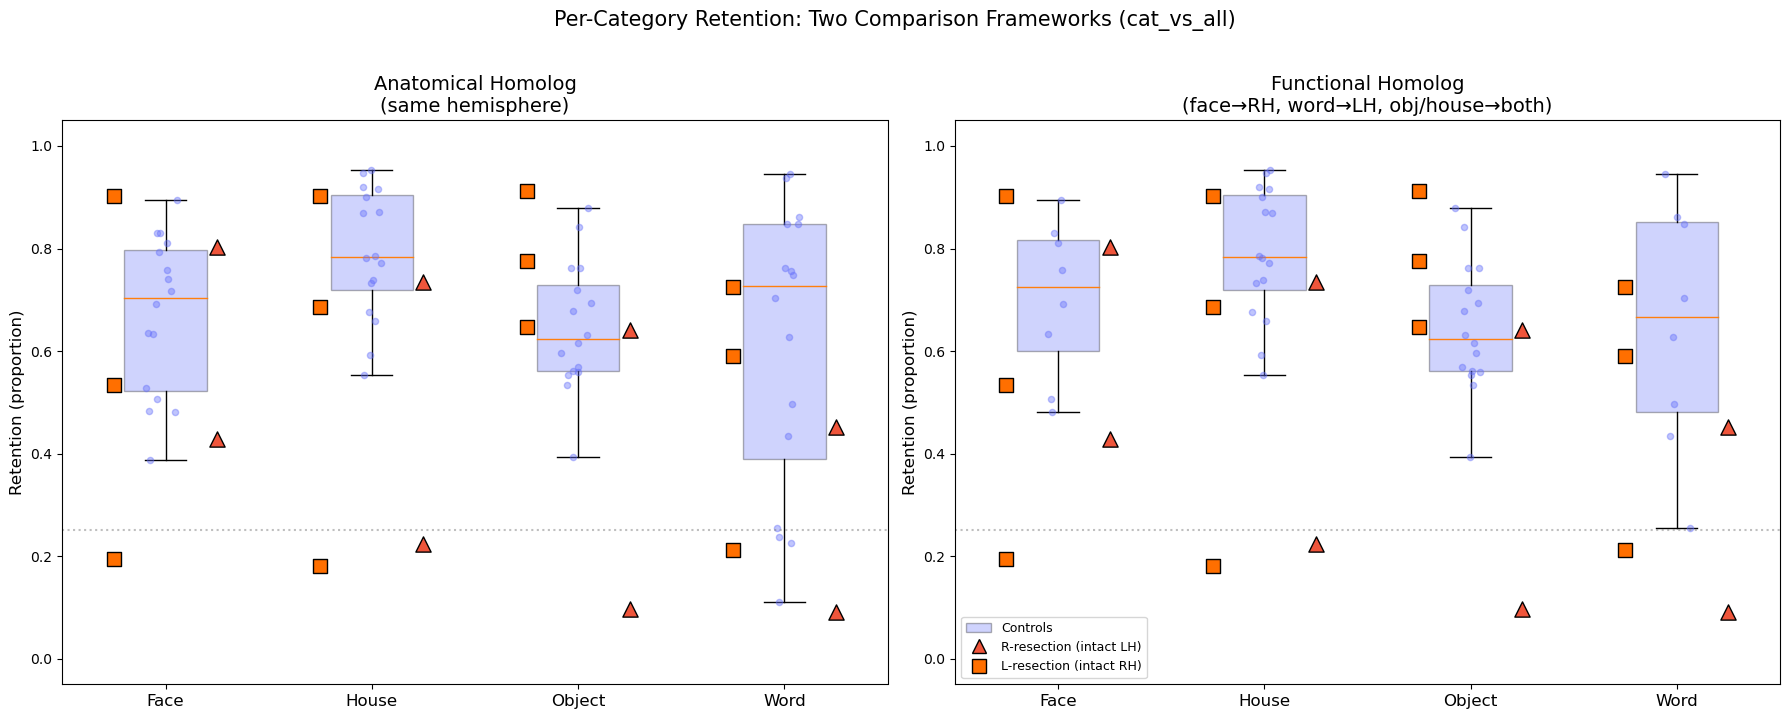

In [17]:
# ── Patients over control distribution: anatomical vs functional ──────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

otc_R_resect = otc_ret[otc_ret['surgery_side'] == 'right']
otc_L_resect = otc_ret[otc_ret['surgery_side'] == 'left']

for panel_idx, (ax, title, ctrl_data_list) in enumerate(zip(
    axes,
    ['Anatomical Homolog\n(same hemisphere)',
     'Functional Homolog\n(face→RH, word→LH, obj/house→both)'],
    [[ctrl_ret_by_hemi['l'][cat] + ctrl_ret_by_hemi['r'][cat] for cat in CATEGORIES],
     [ctrl_ret_functional[cat] for cat in CATEGORIES]]
)):
    x = np.arange(len(CATEGORIES))

    bp = ax.boxplot(ctrl_data_list, positions=x, widths=0.4, patch_artist=True,
                    showfliers=False, zorder=1)
    for patch in bp['boxes']:
        patch.set_facecolor('#636EFA'); patch.set_alpha(0.3)

    for i, cat in enumerate(CATEGORIES):
        vals = ctrl_data_list[i]
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax.scatter(x[i] + jitter, vals, color='#636EFA', alpha=0.4, s=20, zorder=2)

    for _, row in otc_R_resect.iterrows():
        for i, cat in enumerate(CATEGORIES):
            val = row[f'{cat}_retention']
            if np.isfinite(val):
                ax.scatter(x[i] + 0.25, val, marker='^', s=120,
                          color='#EF553B', edgecolor='black', linewidth=1, zorder=3)

    for _, row in otc_L_resect.iterrows():
        for i, cat in enumerate(CATEGORIES):
            val = row[f'{cat}_retention']
            if np.isfinite(val):
                ax.scatter(x[i] - 0.25, val, marker='s', s=100,
                          color='#FF6F00', edgecolor='black', linewidth=1, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in CATEGORIES], fontsize=12)
    ax.set_ylabel('Retention (proportion)', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title, fontsize=14)
    ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5)

legend_elements = [
    Patch(facecolor='#636EFA', alpha=0.3, edgecolor='black', label='Controls'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#EF553B',
           markeredgecolor='black', markersize=10, label='R-resection (intact LH)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF6F00',
           markeredgecolor='black', markersize=10, label='L-resection (intact RH)'),
]
axes[1].legend(handles=legend_elements, fontsize=9, loc='lower left')

plt.suptitle(f'Per-Category Retention: Two Comparison Frameworks ({ALLEGIANCE_COPE_SET})',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'retention_anat_vs_func_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Table

In [18]:
summary_rows = []

for sid, info in long_subs.items():
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        row = {
            'sub': sid, 'hemi': h,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
        }

        if (sid, h) in transition_results:
            row['overall_retention'] = transition_results[(sid, h)]['retention']
            tc = transition_results[(sid, h)]['trans_counts']
            for i, cat in enumerate(CATEGORIES):
                row_total = tc[i, :].sum()
                row[f'{cat}_retention'] = tc[i, i] / row_total if row_total > 0 else np.nan

        if (sid, h) in stability_results:
            row['mean_cos_sim'] = stability_results[(sid, h)]['mean_cos']
            row['median_cos_sim'] = stability_results[(sid, h)]['median_cos']

        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
out_path = os.path.join(processed_dir, 'group_results',
                         f'voxel_allegiance_summary_{ALLEGIANCE_COPE_SET}.csv')
summary_df.to_csv(out_path, index=False)
print(f"Saved summary table: {out_path}")
print()
print(summary_df.to_string(index=False))

Saved summary table: /user_data/csimmon2/sym_pt/group_results/voxel_allegiance_summary_cat_vs_all.csv

    sub hemi   group surgery_side  overall_retention  face_retention  house_retention  object_retention  word_retention  mean_cos_sim  median_cos_sim
sub-004    l     OTC        right           0.686572        0.803047         0.735093          0.641743        0.452381      0.279083        0.392509
sub-007    l  nonOTC         left           0.730902        0.633408         0.745210          0.824996        0.527546      0.383542        0.560662
sub-007    r  nonOTC         left           0.750431        0.690477         0.812028          0.762826        0.285714      0.582798        0.800704
sub-008    l     OTC        right           0.300840        0.427738         0.222849          0.097283        0.091013      0.144242        0.206833
sub-010    r     OTC         left           0.482153        0.195148         0.180124          0.775929        0.211953      0.074219        0.1023

## Notes on Interpretation

**Cope set matters:**
- `raw_beta`: Most neutral but noisy — all categories positive in most voxels
- `cat_vs_all`: Best for allegiance — positive means this category wins
- `differential`: face/house/word all vs object — not ideal for cross-category comparison

**Run with all three and compare.** `cat_vs_all` is probably the most appropriate for allegiance claims.

**The margin diagnostic:** If most voxels have tiny margins, WTA is misleading. If margins are large, WTA is informative.

**Two comparison frameworks:**
- Anatomical homolog is the conservative/standard approach
- Functional homolog tests whether patients differ from controls in the hemisphere that *normally* specializes for that category — more sensitive to crowding effects